<a href="https://colab.research.google.com/github/agisnarevaldo/xai_lime_vs_shap/blob/main/notebooks/03_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — IndoBERT Fine-tuning: Sentiment Analysis (3-class)

Fine-tuning `indobenchmark/indobert-base-p1` on Tokopedia iPhone 17 reviews.

**Labels:** Positif (0) · Negatif (1) · Netral (2)  
**Dataset:** `data/processed/tokopedia_reviews_clean.csv` (1556 rows)  
**Distribution:** Positif≈1495, Negatif≈49, Netral≈12 → class weights to handle imbalance

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**git clone**

In [1]:
import os
import shutil
import subprocess

REPO_URL = "https://github.com/agisnarevaldo/xai_lime_vs_shap.git"
REPO_DIR = "/content/xai_lime_vs_shap"

def run(cmd):
    print("$", " ".join(cmd))
    result = subprocess.run(cmd, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}")
    return result

if os.path.isdir(REPO_DIR):
    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        run(["git", "-C", REPO_DIR, "pull", "--ff-only"])
    else:
        shutil.rmtree(REPO_DIR)
        run(["git", "clone", REPO_URL, REPO_DIR])
else:
    run(["git", "clone", REPO_URL, REPO_DIR])

os.chdir(REPO_DIR)
print("CWD:", os.getcwd())
print("Root contents:", os.listdir("."))

$ git clone https://github.com/agisnarevaldo/xai_lime_vs_shap.git /content/xai_lime_vs_shap
Cloning into '/content/xai_lime_vs_shap'...

CWD: /content/xai_lime_vs_shap
Root contents: ['README.md', 'merge_data.py', '.git', 'full_scrape.py', 'quick_check_new_urls.py', 'merge_new_low_ratings.py', 'scrape_new_urls_deep.py', 'analyze_reviews.py', '.gitignore', 'scrape.ipynb', 'link.txt', 'scrape_additional.py', 'merge_all.py', 'promising_urls.txt', 'config', '.github', 'scrape_low_ratings.py', 'src', 'data', 'scraper.py', 'notebooks']


In [ ]:
## 0. Google Colab Setup
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Google Colab detected — mounting Drive & installing packages …")
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_PROJECT = "/content/xai_lime_vs_shap"
    if os.path.isdir(DRIVE_PROJECT):
        os.chdir(DRIVE_PROJECT)

    import subprocess
    # Added imbalanced-learn for oversampling
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "transformers", "torch", "datasets", "scikit-learn",
         "accelerate", "lime", "shap", "imbalanced-learn"],
        check=True,
    )
    print("Packages ready.")

In [11]:
## 1. Imports & Config
import os, warnings, json
import numpy as np
import pandas as pd
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


def find_project_root() -> Path:
    """Find repository root robustly across VS Code / Jupyter / Colab."""
    markers = ["data", "notebooks", "src"]
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path("/content/xai_lime_vs_shap"),
    ]

    for candidate in candidates:
        if all((candidate / m).exists() for m in markers):
            return candidate

    # Fallback to current directory if markers are not found
    return Path.cwd()


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tokopedia_reviews_clean.csv"
MODEL_DIR = PROJECT_ROOT / "outputs" / "indobert_sentiment"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Make sure project folder contains data/processed/tokopedia_reviews_clean.csv"
    )

# Hyperparameters
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Project root: /content/xai_lime_vs_shap
Data path: /content/xai_lime_vs_shap/data/processed/tokopedia_reviews_clean.csv
Device: cuda
PyTorch: 2.10.0+cu128


In [12]:
## 2. Load & Prepare Data with Oversampling
from imblearn.over_sampling import RandomOverSampler

df = pd.read_csv(DATA_PATH)
LABEL2ID = {"Positif": 0, "Negatif": 1, "Netral": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

df["label"] = df["sentiment_label"].map(LABEL2ID)
df = df.dropna(subset=["review_text_clean", "label"])
df["label"] = df["label"].astype(int)

# Initial Split
X = df[["review_text_clean"]]
y = df["label"]

X_train_raw, X_tmp, y_train_raw, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

# Perform Oversampling only on Training Set
ros = RandomOverSampler(random_state=SEED)
X_train_res, y_train = ros.fit_resample(X_train_raw, y_train_raw)
X_train = X_train_res["review_text_clean"].values

# Convert others to values
X_val = X_val["review_text_clean"].values
X_test = X_test["review_text_clean"].values
y_val = y_val.values
y_test = y_test.values

print(f"Original Train size: {len(X_train_raw)}")
print(f"Oversampled Train size: {len(X_train)}")
print("\nNew Train Label distribution:")
print(pd.Series(y_train).value_counts().rename(index=ID2LABEL))

Original Train size: 1089
Oversampled Train size: 3138

New Train Label distribution:
label
Netral     1046
Positif    1046
Negatif    1046
Name: count, dtype: int64


In [13]:
## 3. Tokenizer & Dataset class

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds = ReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = ReviewDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = ReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"Tokenizer: {MODEL_NAME}")
print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")

Tokenizer: indobenchmark/indobert-base-p1
Train batches: 197  Val batches: 15


In [14]:
## 4. Model Setup (Oversampled Version)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

# Loss function without manual weights (since data is now balanced via ROS)
loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)
print(f"Model ready with balanced training data.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready with balanced training data.


In [15]:
## 5. Training Loop

def eval_model(loader, model, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    return avg_loss, acc, all_preds, all_labels


history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    for step, batch in enumerate(train_loader, 1):
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        if step % 20 == 0:
            print(f"  Epoch {epoch} step {step}/{len(train_loader)} loss={loss.item():.4f}")

    avg_train = train_loss / len(train_loader)
    val_loss, val_acc, _, _ = eval_model(val_loader, model, loss_fn, DEVICE)
    history["train_loss"].append(avg_train)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch}/{EPOCHS} — train_loss={avg_train:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}\n")

print("Training complete.")

  Epoch 1 step 20/197 loss=0.8289
  Epoch 1 step 40/197 loss=0.2999
  Epoch 1 step 60/197 loss=0.0244
  Epoch 1 step 80/197 loss=0.0032
  Epoch 1 step 100/197 loss=0.0020
  Epoch 1 step 120/197 loss=0.0014
  Epoch 1 step 140/197 loss=0.0016
  Epoch 1 step 160/197 loss=0.0012
  Epoch 1 step 180/197 loss=0.0010
Epoch 1/3 — train_loss=0.1894  val_loss=0.2388  val_acc=0.9657

  Epoch 2 step 20/197 loss=0.0021
  Epoch 2 step 40/197 loss=0.0007
  Epoch 2 step 60/197 loss=0.0007
  Epoch 2 step 80/197 loss=0.0009
  Epoch 2 step 100/197 loss=0.0007
  Epoch 2 step 120/197 loss=0.0007
  Epoch 2 step 140/197 loss=0.0005
  Epoch 2 step 160/197 loss=0.0005
  Epoch 2 step 180/197 loss=0.0005
Epoch 2/3 — train_loss=0.0033  val_loss=0.2762  val_acc=0.9657

  Epoch 3 step 20/197 loss=0.0004
  Epoch 3 step 40/197 loss=0.0004
  Epoch 3 step 60/197 loss=0.0004
  Epoch 3 step 80/197 loss=0.0004
  Epoch 3 step 100/197 loss=0.0004
  Epoch 3 step 120/197 loss=0.0004
  Epoch 3 step 140/197 loss=0.0004
  Epoch 3

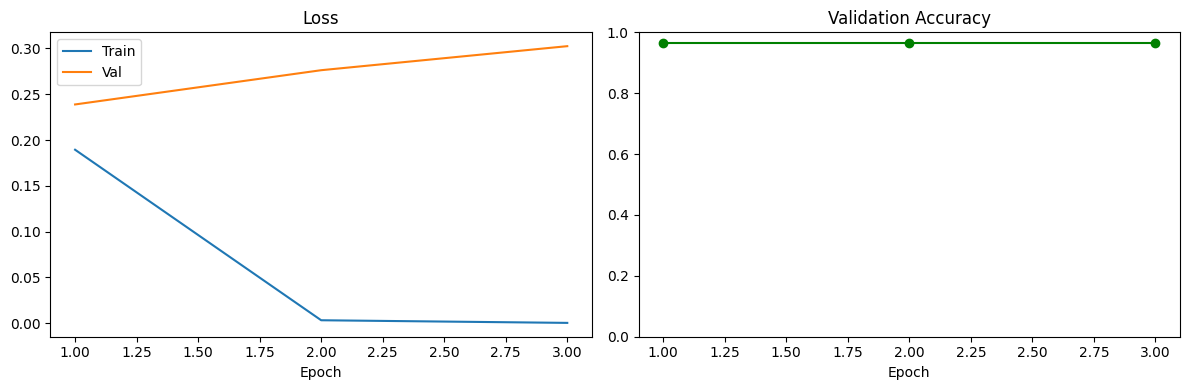

In [16]:
## 6. Training Curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, history["train_loss"], label="Train")
axes[0].plot(epochs_x, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_x, history["val_acc"], color="green", marker="o")
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylim(0, 1)

plt.tight_layout()
(PROJECT_ROOT / "outputs" / "figures").mkdir(parents=True, exist_ok=True)
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "03_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:
## 7. Evaluation on Test Set

test_loss, test_acc, test_preds, test_labels = eval_model(test_loader, model, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}  Test Accuracy: {test_acc:.4f}\n")

target_names = ["Positif", "Negatif", "Netral"]
report = classification_report(test_labels, test_preds, target_names=target_names, zero_division=0)
print(report)

# Save report
(PROJECT_ROOT / "outputs" / "reports").mkdir(parents=True, exist_ok=True)
with open(PROJECT_ROOT / "outputs" / "reports" / "03_classification_report.txt", "w") as f:
    f.write(report)


Test Loss: 0.2638  Test Accuracy: 0.9701

              precision    recall  f1-score   support

     Positif       0.97      1.00      0.98       225
     Negatif       1.00      0.25      0.40         8
      Netral       0.00      0.00      0.00         1

    accuracy                           0.97       234
   macro avg       0.66      0.42      0.46       234
weighted avg       0.97      0.97      0.96       234



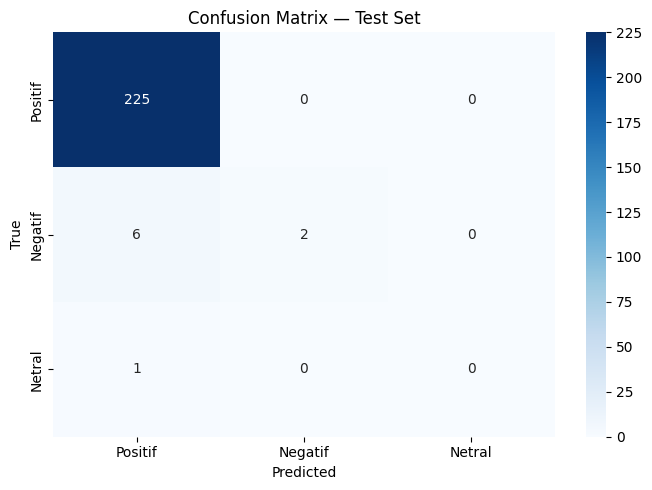

In [19]:
## 8. Confusion Matrix

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "03_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


In [20]:
## 9. Save Model & Tokenizer

model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

# Save label map for notebook 04
with open(MODEL_DIR / "label_map.json", "w") as f:
    json.dump({"id2label": ID2LABEL, "label2id": LABEL2ID}, f, indent=2)

print(f"Model saved → {MODEL_DIR}")
print("Contents:", list(MODEL_DIR.glob("*")))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved → /content/xai_lime_vs_shap/outputs/indobert_sentiment
Contents: [PosixPath('/content/xai_lime_vs_shap/outputs/indobert_sentiment/label_map.json'), PosixPath('/content/xai_lime_vs_shap/outputs/indobert_sentiment/tokenizer_config.json'), PosixPath('/content/xai_lime_vs_shap/outputs/indobert_sentiment/tokenizer.json'), PosixPath('/content/xai_lime_vs_shap/outputs/indobert_sentiment/model.safetensors'), PosixPath('/content/xai_lime_vs_shap/outputs/indobert_sentiment/config.json')]
